# Chapter 49: Text Feature Engineering

**At what typo rate, and at what term coverage, does a character TF-IDF model overtake a word model?**

Step Zero of the chapter is to measure coverage before choosing a representation, with the warning that no universal overlap threshold decides it. This demonstration finds where the switch falls in one controlled setting and shows that it depends on the metric.

*Constructed text and typos injected only at assessment time; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Constructed product-style titles of 7 invented words: four classes, each with 40 class-specific words (30% of the words in its titles) and a shared Zipf-weighted background of 200 words. Models are trained on 800 clean titles and scored on 800 more in which each word is misspelled (substitution, deletion or swap) with the control's probability. Three logistic regressions use TF-IDF with sublinear tf, fitted on training text only: words, characters (analyzer 'char', n-grams 3 to 5, the chapter's baseline) and the two matrices side by side. Coverage is the share of assessment tokens, repeats included, that appear in the training text. All numbers are means over 8 corpora.

In [1]:
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

from kaggle_companion.activities._common import clean

SEED = 49
DRAWS = 8                  # independent corpora; every estimate is a mean over draws
N_DOCS, N_CLASSES, TITLE_WORDS = 800, 4, 7
LETTERS = np.array(list("abcdefghijklmnopqrstuvwxyz"))


def invent_words(rng, n):
    """Pronounceable-enough made-up words of 5 to 9 letters (no real language, so nothing is memorised from outside)."""
    return ["".join(rng.choice(LETTERS, rng.integers(5, 10))) for _ in range(n)]


def misspell(word, rng):
    """One typo: substitute a letter, drop a letter or swap two neighbours."""
    i, kind = rng.integers(len(word)), rng.integers(3)
    if kind == 0:
        return word[:i] + str(rng.choice(LETTERS)) + word[i + 1:]
    if kind == 1 and len(word) > 3:
        return word[:i] + word[i + 1:]
    return word[:i] + word[i + 1] + word[i] + word[i + 2:] if i < len(word) - 1 else word


def titles(n, vocabulary, rng, typo_rate=0.0):
    """Product-style titles: 30% of words come from the class's own list, the rest from a shared Zipf-weighted background."""
    own, background = vocabulary
    weights = 1 / np.arange(1, len(background) + 1)
    weights /= weights.sum()
    labels = rng.integers(0, N_CLASSES, n)
    docs = []
    for c in labels:
        words = [own[c][rng.integers(len(own[c]))] if rng.random() < 0.3 else background[rng.choice(len(background), p=weights)]
                 for _ in range(TITLE_WORDS)]
        docs.append(" ".join(misspell(w, rng) if rng.random() < typo_rate else w for w in words))
    return docs, labels


def coverage(train_docs, test_docs):
    """Step Zero: the share of assessment tokens (counted with repeats, so weighted by frequency) seen in training."""
    seen = set(" ".join(train_docs).split())
    tokens = " ".join(test_docs).split()
    return float(np.mean([t in seen for t in tokens]))


def run(typo_rate):
    rng = np.random.default_rng(SEED)
    names = ("word", "char", "both")
    rows = {k: {"log_loss": [], "accuracy": []} for k in names}
    cover = []
    for _ in range(DRAWS):
        vocabulary = ([invent_words(rng, 40) for _ in range(N_CLASSES)], invent_words(rng, 200))
        train, y_train = titles(N_DOCS, vocabulary, rng)                        # clean training text
        test, y_test = titles(N_DOCS, vocabulary, rng, typo_rate)               # typos appear only here
        cover.append(coverage(train, test))
        word = TfidfVectorizer(analyzer="word", sublinear_tf=True)             # vocabularies are fitted on training text only
        char = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), sublinear_tf=True)
        Wtr, Ctr, Wte, Cte = word.fit_transform(train), char.fit_transform(train), word.transform(test), char.transform(test)
        for name, A, B in (("word", Wtr, Wte), ("char", Ctr, Cte), ("both", hstack([Wtr, Ctr]).tocsr(), hstack([Wte, Cte]).tocsr())):
            p = LogisticRegression(C=10, max_iter=500).fit(A, y_train).predict_proba(B)
            rows[name]["log_loss"].append(log_loss(y_test, p, labels=range(N_CLASSES)))
            rows[name]["accuracy"].append((p.argmax(1) == y_test).mean())
    advantage = np.array(rows["word"]["log_loss"]) - np.array(rows["char"]["log_loss"])      # positive: characters are better
    return clean({
        "typo_rate": typo_rate, "coverage": np.mean(cover),
        **{k: {"log_loss": np.mean(v["log_loss"]), "accuracy": np.mean(v["accuracy"])} for k, v in rows.items()},
        "char_advantage": advantage.mean(), "char_advantage_se": advantage.std(ddof=1) / np.sqrt(DRAWS),
        "char_win_rate": float((advantage > 0).mean()),
        "per_draw": {k: v["log_loss"] for k, v in rows.items()},
        "documents": N_DOCS, "draws": DRAWS,
    })


## Measure it across the control

The control is **share of assessment words that are misspelled**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch49 import explain

VALUES = [0, 0.1, 0.2, 0.4]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                        0    0.1    0.2    0.4
Token coverage      0.999  0.905  0.814  0.630
Word log loss       0.348  0.389  0.434  0.537
Character log loss  0.399  0.413  0.425  0.454
Combined log loss   0.334  0.360  0.389  0.450
Word accuracy       0.900  0.883  0.864  0.811
Character accuracy  0.898  0.896  0.890  0.887


## Look at it

The figure shows the default setting, share of assessment words that are misspelled = 0.2.

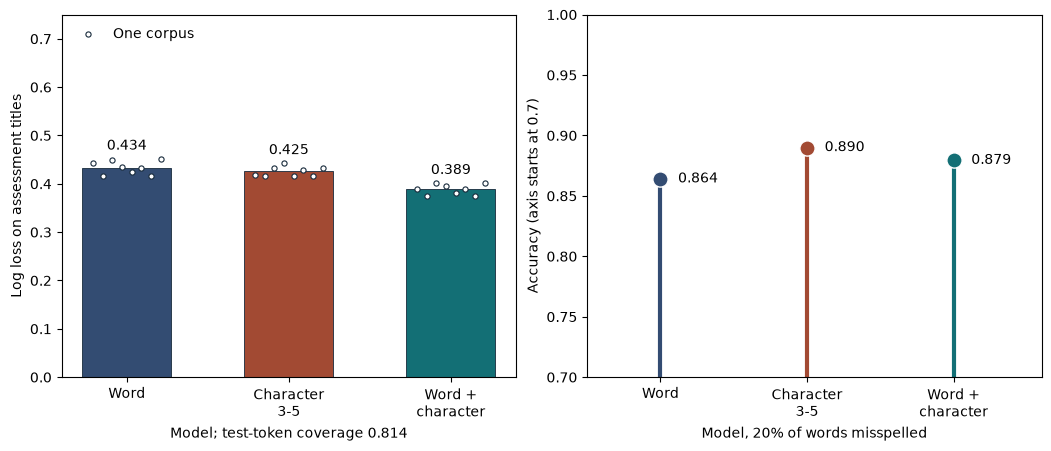

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch49 import draw, NCOLS, HEIGHT

DEFAULT = 0.2
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 20% of assessment words misspelled, 0.814 of assessment tokens are in the training vocabulary. Word log loss is 0.434 and character log loss 0.425: 0.434 - 0.425 = 0.009 (standard error 0.004). The character model is ahead on log loss by a small margin, between two and three standard errors: this is near the switch. Accuracy is 0.864 for words and 0.890 for characters; the combined model has log loss 0.389 and accuracy 0.879.

- Coverage of assessment tokens: 0.814.
- Log loss, word minus character: 0.434 - 0.425 = +0.009 (positive means characters are better).
- Accuracy, character minus word: 0.890 - 0.864 = +0.026.
- Combined model against the better single model: 0.389 - 0.425 = -0.037 log loss.

## Apply this to your competition

- Compute frequency-weighted coverage of the assessment text against the training vocabulary before choosing a representation.
- Compare word, character and combined TF-IDF with a regularised linear model on identical rows, fitted on training text only.
- Judge the comparison by the scored metric: log loss and accuracy can pick different models near the switch.
- Keep the sparse baseline when adding embeddings, and re-check the comparison on text noised the way the test set is.

Book location: Chapter 49, A Small Sparse Comparator.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)